Script to post-process timer outputs
on cooling energy and cooling gap

In [50]:
# import packages 
import os
import pandas as pd
import pym
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import ticker
import matplotlib.ticker as mticker  
from matplotlib.ticker import MaxNLocator


In [268]:
# define and set directories

MAIN_DIR = r'X:/user/crassierc'
IMAGE_REGION_MAPPING_DIR = os.path.join(MAIN_DIR, r'code\geospatial-metadata\mappings')
FIG_DIR = os.path.join(MAIN_DIR, r'code/cooling/CoolingGap/figures/')

# change user directory depending on outputs location #
MAIN_DIR_USER = 'dekkerm'

MAIN_DIR = f'X:/user/{MAIN_DIR_USER}'
if MAIN_DIR_USER == 'crassierc':
    OUTPUT_DIR = os.path.join(MAIN_DIR, r'Projects\PRISMA\2_TIMER\outputlib\TIMER_3_4\PRISMA')
elif MAIN_DIR_USER == 'dekkerm':
    OUTPUT_DIR = os.path.join(MAIN_DIR, r'IMAGE_environments\IMPACTS\2_TIMER\outputlib\TIMER_3_4\IMPACTS')

RESIDENTIAL_DIR = os.path.join(OUTPUT_DIR, r'{}\T2RT\endem\residential')
TUSS_RES_DIR = os.path.join(OUTPUT_DIR, r'{}\tuss\endem\residential')
EMIS_DIR = os.path.join(OUTPUT_DIR, r'{}\tuss\emis')
COOLING_GAP_DIR = os.path.join(OUTPUT_DIR, r'{}\T2RT\cooling_gap')
GMT_DIR = os.path.join(OUTPUT_DIR, r'{}\indicators\Climate')

os.chdir(MAIN_DIR)
print(GMT_DIR)

X:/user/dekkerm\IMAGE_environments\IMPACTS\2_TIMER\outputlib\TIMER_3_4\IMPACTS\{}\indicators\Climate


In [280]:
# load timer output data
appliance_diffusion_fp = os.path.join(TUSS_RES_DIR, 'res_diffusion.out')          # [27,13,11]
energy_use_fp = os.path.join(RESIDENTIAL_DIR, 'ApplEnUse.out')                        # [27,13,11] 
heat_exposed_share_fp = os.path.join(COOLING_GAP_DIR, 'exposed_pop_heat_share.out')   # [26,4]: take median of the the second dimension
heat_exposed_pop_fp = os.path.join(COOLING_GAP_DIR, 'exposed_pop_heat.out')
heat_exposed_pop_median_fp = os.path.join(COOLING_GAP_DIR, 'exposed_pop_heat_median.out')
cooling_gap_pop_fp = os.path.join(COOLING_GAP_DIR, 'cooling_gap_pop.out')             # [27,13,3]
cooling_gap_share_fp = os.path.join(COOLING_GAP_DIR, 'cooling_gap_share.out')             # [27,13,3]
appliance_saturation_fp = os.path.join(COOLING_GAP_DIR, 'saturation_cooling.out')
pop_fp = os.path.join(OUTPUT_DIR, r'{}\indicators\endem\residential\Pop_q.out')                              # regional population
heating_fp = os.path.join(OUTPUT_DIR, r'{}\indicators\endem\residential\res_UESpaceheating.out')  # heating energy use
heating_2_fp = os.path.join(OUTPUT_DIR, r'{}\T2RT\engen\final_energy_buildings_heating.out')  # heating energy use (residential,commercial,total)
CO2_emis_fp = os.path.join(EMIS_DIR, 'CO2Spec2.out')
private_consumption_fp = os.path.join(TUSS_RES_DIR, 'res_pppPCOpc.out')
gmt_fp = os.path.join(GMT_DIR, 'Temp_EST.out')
appliance_access_fp = os.path.join(RESIDENTIAL_DIR, 'res_ApplianceAccess.out')
households_fp = os.path.join(RESIDENTIAL_DIR, 'Households.out')
household_size_fp = os.path.join(RESIDENTIAL_DIR, 'res_HouseholdSize.out')

scenarios = [
    # # SSP2
    # 'SSP2',
    # 'SSP2_NO_GAP_ELEC',
    # 'SSP2_20D',
    # 'SSP2_NO_GAP_ELEC_20D',
    # 'SSP2_NO_GAP_ELEC_SUST_20D',
    # # 'NO_CLIM_IMPACT',
    # # SSP1
    # 'SSP1',
    # 'SSP1_NO_GAP_ELEC',
    # 'SSP1_20D',
    # 'SSP1_NO_GAP_ELEC_20D',
    # 'SSP1_NO_GAP_ELEC_SUST_20D', 
    # # SSP3
    # 'SSP3',
    # 'SSP3_NO_GAP_ELEC',
    # # SSP5
    # 'SSP5',
    # 'SSP5_NO_GAP_ELEC'
    
    # SPARRCLE SCENARIOS
    'IMP-SSP2-REF-noGDPIMP-15',
    'IMP-SSP3-REF-noGDPIMP-15',
    'IMP-SSP2-REF-GDPIMP-15',
    'IMP-SSP3-REF-GDPIMP-15',
     'IMP-SSP2-REF-noGDPIMP-CP'
]
filepaths = {
   'appliance_diffusion': appliance_diffusion_fp,
   'energy_use': energy_use_fp,
#    'heat_exposed_share': heat_exposed_share_fp,
#    'heat_exposed_pop': heat_exposed_pop_fp,
#    'cooling_gap_pop': cooling_gap_pop_fp,
#    'cooling_gap_pop_share': cooling_gap_share_fp,
#    'appliance_saturation': appliance_saturation_fp,
   'pop': pop_fp,
   'emis' : CO2_emis_fp,
   'private_consumption': private_consumption_fp,
   'gmt': gmt_fp,
   # 'heating_energy_use': heating_fp,
   'heating_2_energy_use': heating_2_fp,
#    'appliance_access': appliance_access_fp,
   'households': households_fp,
   'household_size': household_size_fp
} 

# load image region mapping data
region_mapping_fp = os.path.join(IMAGE_REGION_MAPPING_DIR, r'country_to_regions.csv')
region_numbers_fp = os.path.join(IMAGE_REGION_MAPPING_DIR, r'image_region_numbers.csv')

region_mapping = pd.read_csv(region_mapping_fp, encoding='latin-1')
region_numbers = pd.read_csv(region_numbers_fp)

# Load region grid file
# netcdf_path = r'X:\user\daioglouv\Model-Environments\python\BioTool\BioTool\data\SSP2\maps\region27.nc'
# grid_data = xr.open_dataset(netcdf_path)

In [270]:
# load mym output file as array of tuples
def load_files(fp):
    file = pym.read_mym(fp)
    return file

# convert tuple data into xarray dataarray
def create_dataarray(data_tuple):

    data, years = data_tuple
    shape = data.shape
    
    dims = ['year']
    coords = {'year': years}
    dim_names = ['region', 'dim2', 'dim3', 'dim4']
    
    for i, dim_size in enumerate(shape[1:]):
        if i < len(dim_names):
            dim_name = dim_names[i]
            dims.append(dim_name)
            coords[dim_name] = list(range(dim_size))

    da = xr.DataArray(
        data=data,
        dims=dims,
        coords=coords
    )
    
    return da

In [281]:
# loads data and converts to dataarrays
def load_data_as_arrays(filepaths, scenarios):
    result = {}

    for scenario in scenarios:
        result[scenario] = {}

        for name, path_template in filepaths.items():
            formatted_path = path_template.format(scenario)
            data_tuple = load_files(formatted_path)
            result[scenario][name] = create_dataarray(data_tuple)
            
    return result

all_data = load_data_as_arrays(filepaths, scenarios)

**FIGURES**

In [282]:
# plot variables for all regions
def plot_regional_comparison(variable_data, labels, colors, linestyles, title, y_label):
    rows, cols = 6,5
    fig, axes = plt.subplots(rows, cols, figsize=(15, 10), sharex=True)
    axes = axes.flatten()
    years = variable_data[0]['year'].where(variable_data[0]['year']>=2026)
    regions = variable_data[0]['region']

    for i, region in enumerate(regions):
        if i < len(axes):
            ax = axes[i]
            
            for j, dim_data in enumerate(variable_data):
                data = dim_data.sel(region=region)
                ax.plot(years, data, color=colors[j], linestyle=linestyles[j], label=labels[j] if i == 0 else '')
            
            ax.set_title(f'Region {region.values+1}')
            ax.set_ylim(0, 1.5*data.max())
            # ax.set_ylim(0, 1.1)
            ax.grid(True, linestyle='--', alpha=0.7)
            if i % cols == 0:
                ax.set_ylabel(y_label)
    
    for i in range(len(regions), len(axes)):
        axes[i].set_visible(False)
    
    fig.text(0.04, 0.5, y_label, va='center', rotation='vertical', fontsize=14)
    fig.legend(labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=3)
    fig.suptitle(title, fontsize=16)
    
    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

In [284]:
GREY20 = "#333333"

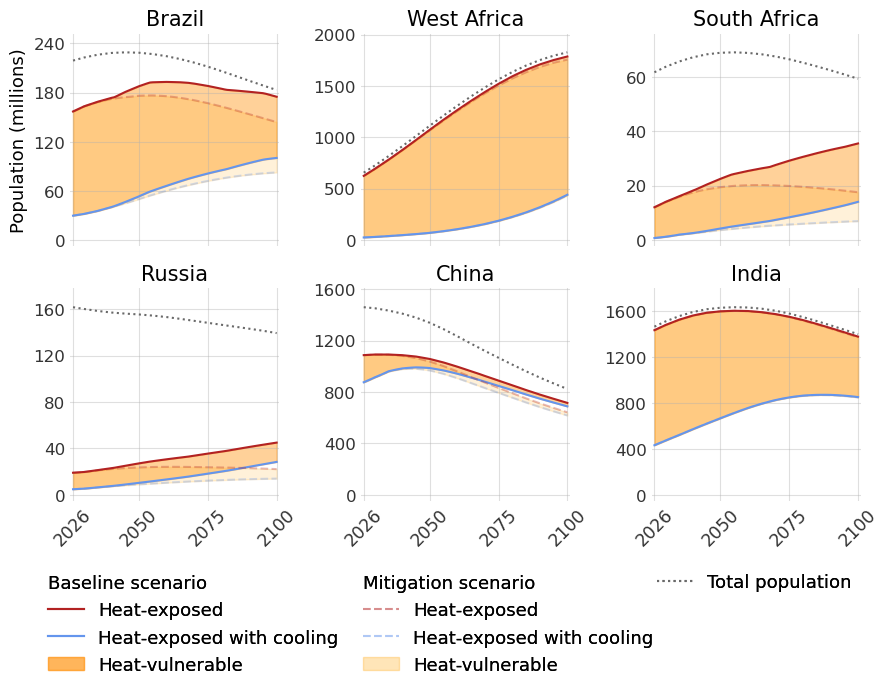

In [104]:
def regional_cooling_gap_plot(ax, years, exposed_pop, exposed_with_cooling, total_pop, region):

    ax.plot(years, exposed_pop['SSP2'], color='firebrick', label='Heat-exposed')
    ax.plot(years, exposed_with_cooling['SSP2'],
            color='cornflowerblue', label='Heat-exposed with cooling')    
    ax.fill_between(years, exposed_pop['SSP2'], exposed_with_cooling['SSP2'],
                    interpolate=True, color='darkorange', alpha=0.4, label='Heat-vulnerable')
    
    ax.plot(years, exposed_pop['SSP2_20D'], color='firebrick', linestyle='--', label='Heat-exposed', alpha=0.3)
    ax.plot(years, exposed_with_cooling['SSP2_20D'],
            color='cornflowerblue', label='Heat-exposed with cooling', linestyle='--', alpha=0.3)
    ax.fill_between(years, exposed_pop['SSP2_20D'], exposed_with_cooling['SSP2_20D'],
                    interpolate=False, color='orange', alpha=0.15, label='Heat-vulnerable')
    
    ax.plot(years, total_pop, color='dimgrey', linestyle='dotted', label='Total population')

    xticks = [2026, 2050, 2075, 2100]
    if i > 0:
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks, color=GREY20, fontsize=12.5)
    elif i == 0:
        ax.set_xticks([])
    
    ax.tick_params(axis='x', labelrotation=45)
    ax.yaxis.set_major_formatter(
        ticker.FormatStrFormatter('%0.0f'))
    for label in ax.get_yticklabels():
        label.set_color(GREY20)
        label.set_fontsize(12)
    ax.yaxis.set_major_locator(MaxNLocator(5))
    
    ax.yaxis.set_tick_params(which="both", length=0)
    ax.xaxis.set_tick_params(which="both", length=0)
    
    ax.set_xlim(2025, 2101)
    ax.set_ylim(-3e-2*region_max, 1.1*region_max)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.grid(which="major", lw=0.8, alpha=0.4)
    ax.set_title(region, color='black', fontsize=15)
    y_label = 'Population (millions)'
    axes[0].set_ylabel(y_label, color='black', fontsize=13)

region_names = ['Brazil', 'West Africa', 'South Africa', 'Russia', 'China', 'India']
regions_list = [4, 7, 9, 15, 19, 17]
n_regions = len(regions_list)
cols = min(3, n_regions)
rows = (n_regions + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(9, 6), sharex=True)
axes = axes.flatten()

for i, region in enumerate(regions_list):
    ax = axes[i]
    years = np.arange(2026, 2101)

    total_pop = all_data['SSP2']['pop'].sel(
         year=years, region=region, dim2=0) / 1e6

    exposed_pop = {}
    exposed_with_cooling = {}
    scens = ['SSP2', 'SSP2_20D']
    
    for scen in scens:
        filtered_data = all_data[scen]
        
        exposed_pop[scen] = filtered_data['heat_exposed_pop'].sel(
         year=years, region=region, dim2=0) / 1e6

        exposed_with_cooling[scen] = 0
        quintiles = list(range(3,12))
        for quintile in quintiles:
                heat_exposed_per_quintile = filtered_data['heat_exposed_pop'].sel(
                    year=years, region=region, dim2=quintile)
                appliance_ability_per_quintile = filtered_data['appliance_diffusion'].sel(
                    year=years, region=region, dim2=quintile, dim3=slice(1,2)
                    ).sum('dim3') / (
                         filtered_data['appliance_saturation'].sel(
                    year=years, region=region, dim2=quintile, dim3=slice(1,2)
                    ).sum('dim3'))
                exposed_with_cooling_per_quintile = (
                    heat_exposed_per_quintile -
                    heat_exposed_per_quintile * (
                        1 - appliance_ability_per_quintile)) / 1e6
                exposed_with_cooling[scen] += exposed_with_cooling_per_quintile

    region_max = max(total_pop)
    region_name = region_names[i]

    regional_cooling_gap_plot(ax, years,
                exposed_pop, exposed_with_cooling,
                total_pop, f"{region_name}")

handles, labels = axes[0].get_legend_handles_labels()
legend1 = fig.legend(handles[:3], labels[:3], loc='center right', ncol=1,
        #    bbox_to_anchor=(1.35, 0.57),
           bbox_to_anchor=(0.4, -0.1),
           fontsize=13, title_fontsize = 13, frameon=False,
           title='Baseline scenario')
legend1._legend_box.align = "left"
ax.add_artist(legend1)

legend2 = fig.legend(handles[3:6], labels[3:6], loc='center right', ncol=1,
        #    bbox_to_anchor=(1.35, 0.35),
           bbox_to_anchor=(0.75, -0.1),
           fontsize=13, title_fontsize = 13, frameon=False,
           title='Mitigation scenario')
legend2._legend_box.align = "left"
ax.add_artist(legend2)

legend3 = fig.legend(handles[6:], labels[6:], loc='center right', ncol=1,
        #    bbox_to_anchor=(1.245, 0.20),
           bbox_to_anchor=(0.97, -0.03),
           fontsize=13, frameon=False)
ax.add_artist(legend3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig(os.path.join(FIG_DIR, 'RegionalCoolingGap.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [105]:
def plot_specific_regional_comparison(variable_data, labels, colors, linestyles, title,
                                      y_label, regions_list=None, region_names=None):
    all_regions = variable_data[0]['region']
    
    if regions_list is None:
        regions_to_plot = all_regions
    else:
        regions_to_plot = [r for r in regions_list if r in all_regions]
        if len(regions_to_plot) == 0:
            print("No valid regions found in the provided regions_list!")
            return
    
    n_regions = len(regions_to_plot)
    cols = min(3, n_regions)
    rows = (n_regions + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows), sharex=True)
    
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
    
    years = variable_data[0]['year'].where(variable_data[0]['year'] >= 2026)
    
    # Plot each region
    for i, region in enumerate(regions_to_plot):
        if i < len(axes):
            ax = axes[i]
            
            region_max = 0
            for dim_data in variable_data:
                if isinstance(region, (int, np.integer)):
                    data = dim_data.sel(region=region)
                else:
                    data = dim_data.sel(region=region.item())
                current_max = data.max().item() if hasattr(data.max(), 'item') else data.max()
                region_max = max(region_max, current_max)
            
            for j, dim_data in enumerate(variable_data):
                if isinstance(region, (int, np.integer)):
                    data = dim_data.sel(region=region)
                else:
                    data = dim_data.sel(region=region.item())
                
                ax.plot(years, data, color=colors[j], linestyle=linestyles[j],
                        label=labels[j] if i == 0 else '')
                ax.set_axisbelow(True)
                ax.grid(True, linestyle='', alpha=0.7)
                # ax.set_ylim(0,1)
                ax.set_ylim(0, 1.1*region_max)
                ax.set_xlim(2025,2100)
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)

                region_title = region_names[i]
                
                ax.fill_between(data.values, data.values, interpolate=True, color='orange', alpha=0.3) 

            ax.set_title(region_title, fontsize=13)

    for i in range(n_regions, len(axes)):
        axes[i].set_visible(False)
    
    fig.text(0.01, 0.5, y_label, va='center', rotation='vertical', fontsize=13)
    fig.legend(labels, loc='lower center', bbox_to_anchor=(0.5, -0.07), ncol=2, frameon=False, fontsize=13)
    
    plt.tight_layout(rect=[0.043, 0.08, 0.95, 0.95])
    plt.savefig(FIG_DIR + f'{title}.pdf', bbox_inches='tight')
    plt.show()

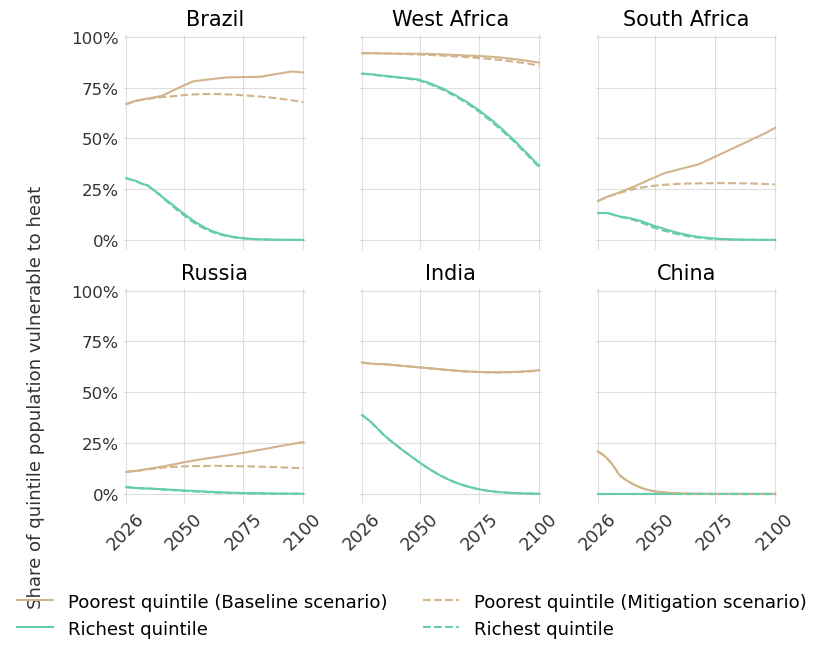

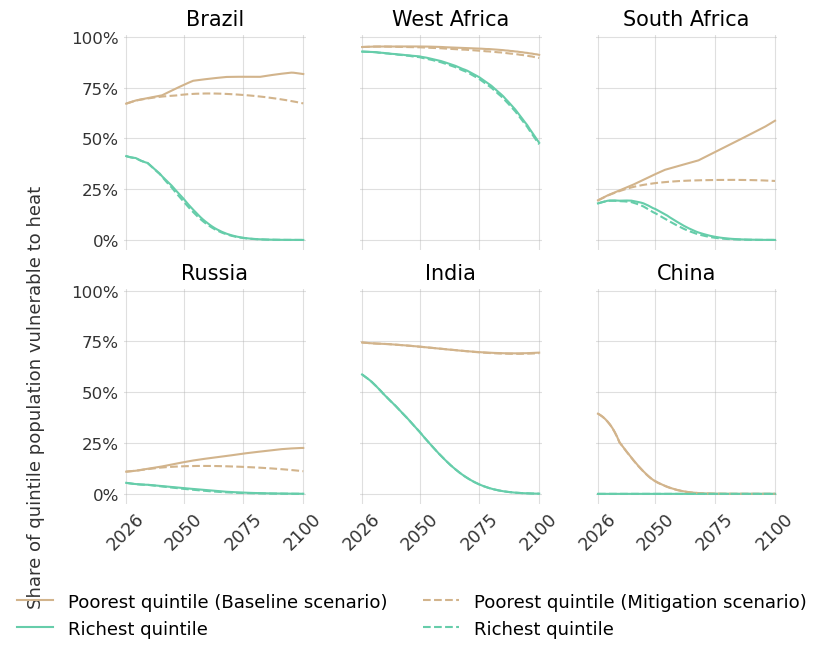

In [106]:
def plot_income_quintiles(variable_data_dict, labels, colors, linestyles, title,
                                       y_label, regions_list=None, region_names=None):
    
    first_scen = list(variable_data_dict.keys())[0]
    all_regions = variable_data_dict[first_scen][0]['region']
    regions_to_plot = [r for r in regions_list if r in all_regions]
    n_regions = len(regions_to_plot)
    cols = 3
    rows = 2
    fig, axes = plt.subplots(rows, cols, figsize=(8,6), sharex=True)
    years = variable_data_dict[first_scen][0]['year'].where(variable_data_dict[first_scen][0]['year'] >= 2026)
    
    for i, region in enumerate(regions_to_plot):
        row = i // cols
        col = i % cols
        ax = axes[row, col]
        
        plot_idx = 0
        for scen in variable_data_dict:
            for dim_data in variable_data_dict[scen]:
                if isinstance(region, (int, np.integer)):
                    data = dim_data.sel(region=region)
                else:
                    data = dim_data.sel(region=region.item())
                
                ax.plot(years, data, color=colors[plot_idx], linestyle=linestyles[plot_idx],
                        label=labels[plot_idx] if i == 0 else '')
                plot_idx += 1
        
        ax.set_axisbelow(True)
        major_yticks = np.arange(0, 1.1, 0.25)
        ax.set_yticks(major_yticks)
        ax.grid(True, axis='both', which='major', linestyle='-', alpha=0.4, linewidth=0.8)
        ax.set_ylim(-0.05, 1.01)
        ax.set_xlim(2025, 2101)
        major_xticks = [2026,2050,2075,2100]
        ax.set_xticks(major_xticks)
        ax.set_xticklabels(major_xticks, color=GREY20, fontsize=12.5)
        ax.yaxis.set_tick_params(which="both", length=0)
        ax.xaxis.set_tick_params(which="both", length=0, rotation=45)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        if col > 0:
            ax.set_yticklabels([])
        if col == 0:
            ax.set_yticklabels([f'{int(y*100)}%' for y in major_yticks], color=GREY20, fontsize=12)

        region_title = region_names[i]
        ax.set_title(region_title, color='black', fontsize=15, pad=7)
        axes[1,0].set_ylabel(y_label, color=GREY20, fontsize=13)

    for i in range(n_regions, rows * cols):
        row = i // cols
        col = i % cols
        axes[row, col].set_visible(False)
        
    legend = fig.legend(labels, loc='lower center', bbox_to_anchor=(0.5, -0.1),
               ncol=2, frameon=False, fontsize=13)
    plt.setp(legend.get_label(), color=GREY20)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    # plt.savefig(FIG_DIR + f'{title}.pdf', bbox_inches='tight', dpi=300)
    plt.show()

scens = ['SSP2', 'SSP2_20D']

urban_data = {scen: [all_data[scen]['cooling_gap_pop_share'].sel(dim2=d) for d in [3, 7]] for scen in scens}
plot_income_quintiles(
    variable_data_dict=urban_data,
    labels=['Poorest quintile (Baseline scenario)', 'Richest quintile',
            'Poorest quintile (Mitigation scenario)', 'Richest quintile'],
    colors=['tan', 'mediumaquamarine', 'tan', 'mediumaquamarine'],
    linestyles=['solid', 'solid', 'dashed', 'dashed'],
    title='income_quintiles_cooling_gap_urban',
    y_label='Share of quintile population vulnerable to heat\n',
    regions_list=[4, 7, 9, 15, 17, 19],
    region_names=['Brazil', 'West Africa', 'South Africa', 'Russia', 'India', 'China']
)

rural_data = {scen: [all_data[scen]['cooling_gap_pop_share'].sel(dim2=d) for d in [8, 12]] for scen in scens}
plot_income_quintiles(
    variable_data_dict=rural_data,
    labels=['Poorest quintile (Baseline scenario)', 'Richest quintile',
            'Poorest quintile (Mitigation scenario)', 'Richest quintile'],
    colors=['tan', 'mediumaquamarine', 'tan', 'mediumaquamarine'],
    linestyles=['solid', 'solid', 'dashed', 'dashed'],
    title='income_quintiles_cooling_gap_rural',
    y_label='Share of quintile population vulnerable to heat\n',
    regions_list=[4, 7, 9, 15, 17, 19],
    region_names=['Brazil', 'West Africa', 'South Africa', 'Russia', 'India', 'China']
)

In [107]:
# plot global variables
def plot_global_comparison(variable_data, labels, colors, title, y_label):
    
    rows, cols = 1,1
    fig, ax = plt.subplots(rows, cols, figsize=(8,6))
    
    years = variable_data[0]['year'].where(variable_data[0]['year']>=2026)

    for i, dim_data in enumerate(variable_data):
        data = dim_data
        ax.plot(years, data, color=colors[i], label=labels[i] if i == 0 else '')

    ax.set_ylim(0, 1.1)
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', alpha=0.7)

    fig.text(0.04, 0.5, y_label, va='center', rotation='vertical', fontsize=14)
    fig.legend(labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=3)
    fig.suptitle(title, fontsize=16)

    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

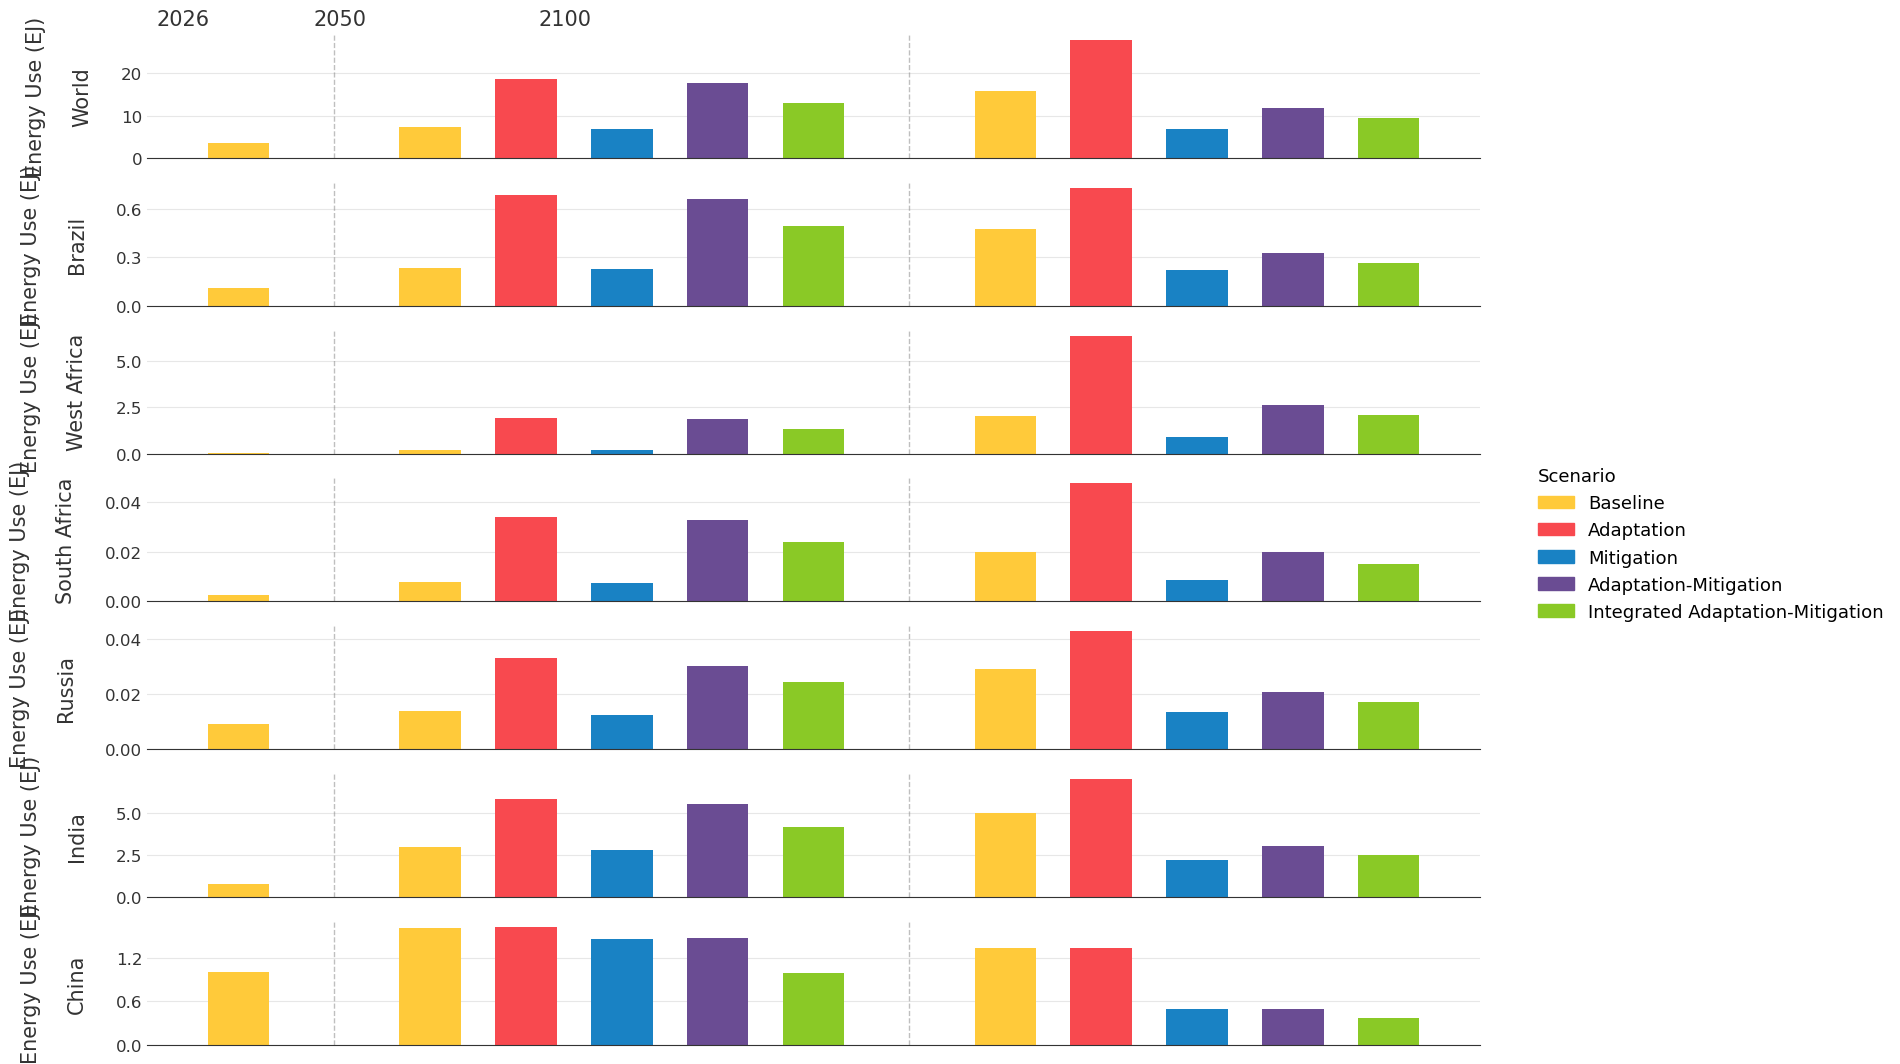

In [126]:
def plot_energy_use_by_year_and_scenario(all_data, regions, region_names, title):
    
    target_years = [2025, 2050, 2100]
    all_scenarios = {
        'SSP2': 'Baseline',
        'SSP2_NO_GAP_ELEC': 'Adaptation',
        'SSP2_20D': 'Mitigation',
        'SSP2_NO_GAP_ELEC_20D': 'Adaptation-Mitigation',
        'SSP2_NO_GAP_ELEC_SUST_20D': 'Integrated Adaptation-Mitigation',
    }
    scenario_keys = list(all_scenarios.keys())
    scenario_labels = list(all_scenarios.values())
    
    n_regions = len(regions)
    n_scenarios = len(all_scenarios)
    fig, axes = plt.subplots(n_regions, 1, figsize=(15, 1.5*n_regions))
 
    colors = {'SSP2': '#ffca3a', 'SSP2_20D': '#1982c4',
              'SSP2_NO_GAP_ELEC': '#F8494F', 'SSP2_NO_GAP_ELEC_20D': '#6a4c93',
              'SSP2_NO_GAP_ELEC_SUST_20D': '#8ac926',
              }
    
    bar_width = 0.8
    scenario_width = bar_width / n_scenarios
    
    for row, (region, region_name) in enumerate(zip(regions, region_names)):
        ax = axes[row]
        
        for year_idx, year in enumerate(target_years):
            scenarios_for_year = ['SSP2'] if year == 2025 else scenario_keys
            
            for j, scenario in enumerate(scenarios_for_year):
                value_air_cooler = all_data[scenario]['energy_use'].sel(
                    year=year, region=region, dim2=0, dim3=1).item()
                value_air_conditioner = all_data[scenario]['energy_use'].sel(
                    year=year, region=region, dim2=0, dim3=2).item()
                value = (value_air_cooler + value_air_conditioner) / 1e9
                
                if year == 2025:
                    x_pos = 1
                elif year == 2050:
                    x_pos = (j/4 + year_idx * n_scenarios) - 3.5
                else:
                    x_pos = (j/4 + year_idx * n_scenarios) - 7
                
                scenario_idx = scenario_keys.index(scenario)
                bars = ax.bar(x_pos, value, scenario_width,
                             color=colors[scenario], alpha=1,
                             label=scenario_labels[scenario_idx] if year_idx == 1 and j == 0 else '',
                             zorder=2)
        
        ax.axvline(x=1.25, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.axvline(x=2.75, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.yaxis.set_major_locator(MaxNLocator(3))
        for label in ax.get_yticklabels():
            label.set_color(GREY20)
            label.set_fontsize(12)
        ax.set_xticks([])
        ax.set_ylabel(f'Energy Use (EJ)\n\n{region_name}', color=GREY20, fontsize=15)
        ax.grid(True, axis='y', linestyle='-', alpha=0.3, linewidth=0.8, zorder=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_color(GREY20)
        ax.yaxis.set_tick_params(which="both", length=0)
        ax.xaxis.set_tick_params(which="both", length=0)

    # Build legend only from first row to avoid duplicates
    import matplotlib.patches as mpatches
    handles = [mpatches.Patch(color=colors[s], label=all_scenarios[s]) for s in scenario_keys]
    legend = fig.legend(handles=handles, loc='center right', frameon=False, 
                        fontsize=13, bbox_to_anchor=(1.27, 0.5),
                        title='Scenario', title_fontsize=13)
    legend._legend_box.align = "left"

    fig.text(0.125, 1, '2026', fontsize=15, color=GREY20, ha='center', va='center')
    fig.text(0.23, 1, '2050', fontsize=15, color=GREY20, ha='center', va='center')
    fig.text(0.38, 1, '2100', fontsize=15, color=GREY20, ha='center', va='center')

    plt.tight_layout()
    plt.savefig(FIG_DIR + f'{title}_single_axis.pdf', bbox_inches='tight', dpi=300)
    plt.show()

plot_energy_use_by_year_and_scenario(all_data,
                                     regions=[26,4,7,9,15,17,19],
                                     region_names=['World\n', 'Brazil\n', 'West Africa\n',
                                                   'South Africa\n', 'Russia\n', 'India\n', 'China\n'],
                                     title='Energy_demand_ssp2_bargraph')

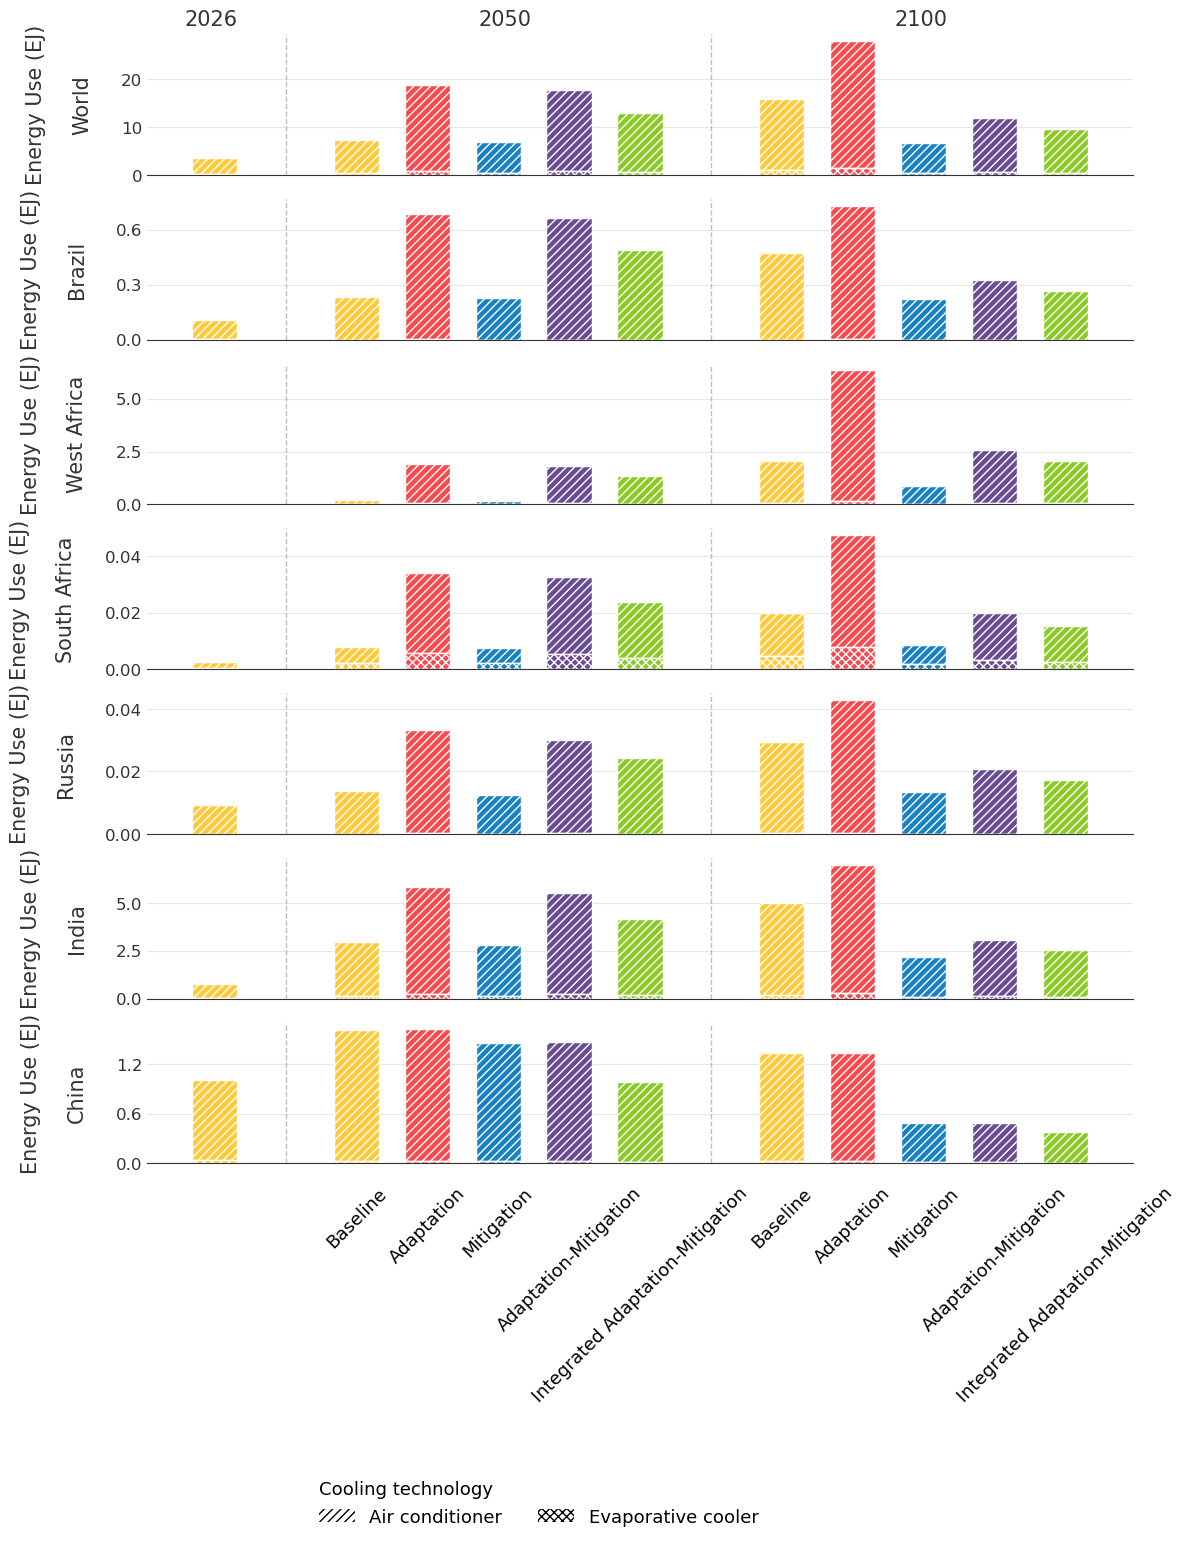

In [133]:
def plot_energy_use_by_tech_and_scenario(all_data, regions, region_names, title):
    
    target_years = [2025, 2050, 2100]
    all_scenarios = {
        'SSP2': 'Baseline',
        'SSP2_NO_GAP_ELEC': 'Adaptation',
        'SSP2_20D': 'Mitigation',
        'SSP2_NO_GAP_ELEC_20D': 'Adaptation-Mitigation',
        'SSP2_NO_GAP_ELEC_SUST_20D': 'Integrated Adaptation-Mitigation',
    }
    scenario_keys = list(all_scenarios.keys())
    scenario_labels = list(all_scenarios.values())
    
    n_regions = len(regions)
    n_scenarios = len(all_scenarios)
    fig, axes = plt.subplots(n_regions, 1, figsize=(12, 2*n_regions))
 
    colors = {'SSP2': '#ffca3a', 'SSP2_20D': '#1982c4',
              'SSP2_NO_GAP_ELEC': '#F8494F', 'SSP2_NO_GAP_ELEC_20D': '#6a4c93',
              'SSP2_NO_GAP_ELEC_SUST_20D': '#8ac926',
              }
    hatches = ["////", 'xxxx']
    
    bar_width = 0.8
    scenario_width = bar_width / n_scenarios
    
    for row, (region, region_name) in enumerate(zip(regions, region_names)):
        ax = axes[row]
        
        for year_idx, year in enumerate(target_years):
            scenarios_for_year = ['SSP2'] if year == 2025 else scenario_keys
            
            for j, scenario in enumerate(scenarios_for_year):
                value_air_conditioner = all_data[scenario]['energy_use'].sel(
                    year=year, region=region, dim2=0, dim3=2).item()/ 1e9
                value_air_cooler = all_data[scenario]['energy_use'].sel(
                    year=year, region=region, dim2=0, dim3=1).item()/ 1e9
                
                if year == 2025:
                    x_pos = 1
                elif year == 2050:
                    x_pos = (j/4 + year_idx * n_scenarios) - 3.5
                else:
                    x_pos = (j/4 + year_idx * n_scenarios) - 7
                
                scenario_idx = scenario_keys.index(scenario)

                bars1 = ax.bar(x_pos, value_air_conditioner, scenario_width,
                             color=colors[scenario], alpha=1,
                             hatch=hatches[0],
                             edgecolor='white',
                             bottom=value_air_cooler,
                             label=scenario_labels[scenario_idx] if year_idx == 1 and scenario == scenario_labels[scenario_idx] else '',
                             zorder=2)
                bars2 = ax.bar(x_pos, value_air_cooler, scenario_width,
                             color=colors[scenario], alpha=1, 
                             hatch=hatches[1],
                             edgecolor='white',
                             label=scenario_labels[scenario_idx] if year_idx == 1 and scenario == scenario_labels[scenario_idx] else '',
                             zorder=2)
                if row == n_regions-1:
                    if  year != 2025:
                        ax.text(x_pos, -0.25, scenario_labels[scenario_idx],
                                ha='center', va='top', rotation=45, fontsize=13, color='black')

        ax.axvline(x=1.25, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.axvline(x=2.75, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.yaxis.set_major_locator(MaxNLocator(3))
        for label in ax.get_yticklabels():
            label.set_color(GREY20)
            label.set_fontsize(12)
        ax.set_xticks([])
        ax.set_ylabel(f'Energy Use (EJ)\n\n{region_name}', color=GREY20, fontsize=15)
        ax.grid(True, axis='y', linestyle='-', alpha=0.3, linewidth=0.8, zorder=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_color(GREY20)
        ax.yaxis.set_tick_params(which="both", length=0)
        ax.xaxis.set_tick_params(which="both", length=0)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='white', hatch=hatches[0], label='Air conditioner'),
        Patch(facecolor='white', hatch=hatches[1], label='Evaporative cooler')
    ]
    legend = fig.legend(handles=legend_elements,
                        loc='center right',
                        frameon=False,
                        fontsize=13,
                        bbox_to_anchor=(0.65, -0.06),
                        ncol=2,
                        title='Cooling technology',
                        title_fontsize=13)
    legend._legend_box.align = "left"

    fig.text(0.18, 1, '2026', fontsize=15, color=GREY20, ha='center', va='center')
    fig.text(0.425, 1, '2050', fontsize=15, color=GREY20, ha='center', va='center')
    fig.text(0.772, 1, '2100', fontsize=15, color=GREY20, ha='center', va='center')

    plt.tight_layout()
    plt.savefig(FIG_DIR + f'{title}_single_axis.pdf', bbox_inches='tight', dpi=300)
    plt.show()

plot_energy_use_by_tech_and_scenario(all_data,
                                      regions=[26,4,7,9,15,17,19],
                                      region_names=['World\n',
                                                    'Brazil\n',
                                                    'West Africa\n',
                                                    'South Africa\n',
                                                    'Russia\n',
                                                    'India\n',
                                                    'China\n'
                                                    ],
                                        title='Energy_demand_tech_ssp2'
                                      )

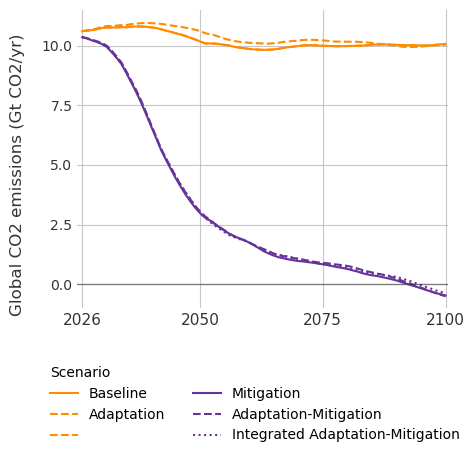

In [73]:
def plot_emissions(variable_data, labels, colors, linestyles, title, y_label):

    fig, ax = plt.subplots(figsize=(5,4))  
    filtered_data = [data.where(data['year'] >= 2026, drop=True) for data in variable_data]
    years = filtered_data[0]['year']    
    current_max = 0

    current_max = 0
    for data in filtered_data:
        data_max = data.max().item() if hasattr(data.max(), 'item') else data.max()
        current_max = max(current_max, data_max)

    for j, data in enumerate(filtered_data):
        plt.plot(years, data, color=colors[j], linestyle=linestyles[j], label=labels[j])

    ax.set_axisbelow(True)
    yticks = [0,2.5,5,7.5,10]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=10, color=GREY20)
    plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    xticks=[2026,2050,2075,2100]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, fontsize=11, color=GREY20)
    ax.grid(True, linestyle='-', axis='both', alpha=0.7)
    ax.set_ylim(-1, 1.05*current_max)
    ax.set_xlim(2025,2100.5)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.yaxis.set_tick_params(which="both", length=0)
    ax.xaxis.set_tick_params(which="both", length=0)
    ax.axhline(y=0, color=GREY20, linestyle='-', alpha=0.5, linewidth=1)
    
    fig.text(0.01, 0.5, y_label, va='center', rotation='vertical', fontsize=12, color=GREY20)
    legend = fig.legend(labels, loc='lower center', bbox_to_anchor=(0.5, -0.2),
               ncol=2, frameon=False, fontsize=10, title='Scenario', title_fontsize=10)
    legend._legend_box.align = "left"
    plt.tight_layout(rect=[0.043, 0.08, 0.95, 0.95])
    plt.title('')
    plt.savefig(FIG_DIR + f'{title}.pdf', bbox_inches='tight')
    plt.show()

blank_data = all_data['SSP2']['emis'].sel(region=27, dim2=20, dim3=6)
emis_ssp2_data = all_data['SSP2']['emis'].sel(region=27, dim2=20, dim3=6)
emis_2dC_data = all_data['SSP2_20D']['emis'].sel(region=27, dim2=20, dim3=6)
emis_high_adaptation_data = all_data['SSP2_NO_GAP_ELEC']['emis'].sel(region=27, dim2=20, dim3=6)
emis_high_adaptation_2dC_data = all_data['SSP2_NO_GAP_ELEC_20D']['emis'].sel(region=27, dim2=20, dim3=6)
emis_integ_high_adaptation_2dC_data = all_data['SSP2_NO_GAP_ELEC_SUST_20D']['emis'].sel(region=27, dim2=20, dim3=6)
plot_emissions(
     variable_data=[
          emis_ssp2_data,
          emis_high_adaptation_data,
          blank_data,
          emis_2dC_data,
          emis_high_adaptation_2dC_data,
          emis_integ_high_adaptation_2dC_data
     ],
     labels=[
          'Baseline',
          'Adaptation',
          '',
          'Mitigation',
          'Adaptation-Mitigation',
          'Integrated Adaptation-Mitigation'
     ],
     colors=[
            'darkorange',
            'darkorange',
            'darkorange',
            'rebeccapurple',
            'rebeccapurple',
            'rebeccapurple'
     ],
     linestyles=[
            'solid',
            'dashed',
            'dashed',
            'solid',
            'dashed',
            'dotted'
     ],
     title='emissions_ssp2',
     y_label='Global CO2 emissions (Gt CO2/yr)'
)

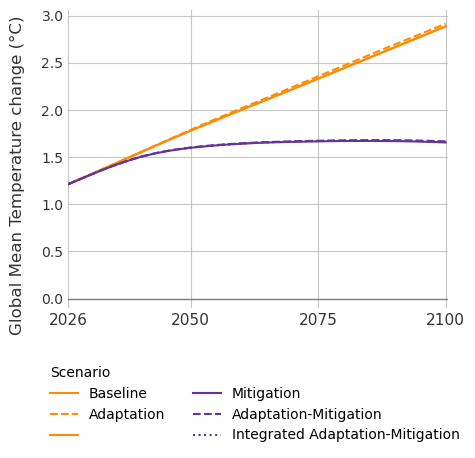

In [135]:
def plot_gmt(scenarios, colors, linestyles, title, y_label):

    fig, ax = plt.subplots(figsize=(5,4))

    variable_data = [
        all_data[s]['gmt'] if not s.startswith('__') else all_data['SSP2']['gmt']
        for s in scenarios
    ]
    labels = list(scenarios.values())
    filtered_data = [data.where(data['year'] >= 2026, drop=True) for data in variable_data]
    years = filtered_data[0]['year']

    current_max = 0
    for data in filtered_data:
        data_max = data.max().item() if hasattr(data.max(), 'item') else data.max()
        current_max = max(current_max, data_max)

    for j, data in enumerate(filtered_data):
        ax.plot(years, data, color=colors[j], linestyle=linestyles[j], label=labels[j])

    ax.set_axisbelow(True)
    yticks = [0, 0.5, 1, 1.5, 2, 2.5, 3]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=10, color=GREY20)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    xticks = [2026, 2050, 2075, 2100]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, fontsize=11, color=GREY20)
    ax.grid(True, linestyle='-', axis='both', alpha=0.7)
    ax.set_ylim(-0.1, 1.05 * current_max)
    ax.set_xlim(2026, 2100.5)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.yaxis.set_tick_params(which="both", length=0)
    ax.xaxis.set_tick_params(which="both", length=0)
    ax.axhline(y=0, color=GREY20, linestyle='-', alpha=0.5, linewidth=1)

    fig.text(0.01, 0.5, y_label, va='center', rotation='vertical', fontsize=12, color=GREY20)
    legend = fig.legend(labels, loc='lower center', bbox_to_anchor=(0.5, -0.2),
                        ncol=2, frameon=False, fontsize=10, title='Scenario', title_fontsize=10)
    legend._legend_box.align = "left"
    plt.tight_layout(rect=[0.043, 0.08, 0.95, 0.95])
    # plt.savefig(FIG_DIR + f'{title}.pdf', bbox_inches='tight')
    plt.show()

scenarios = {
    'SSP2': 'Baseline',
    'SSP2_NO_GAP_ELEC': 'Adaptation',
    '__gap__': '',
    'SSP2_20D': 'Mitigation',
    'SSP2_NO_GAP_ELEC_20D': 'Adaptation-Mitigation',
    'SSP2_NO_GAP_ELEC_SUST_20D': 'Integrated Adaptation-Mitigation',
}
colors     = ['darkorange', 'darkorange', 'darkorange', 'rebeccapurple', 'rebeccapurple', 'rebeccapurple']
linestyles = ['solid', 'dashed', 'solid', 'solid', 'dashed', 'dotted']

plot_gmt(scenarios, colors, linestyles, title='gmt_ssp2', y_label='Global Mean Temperature change (°C)')

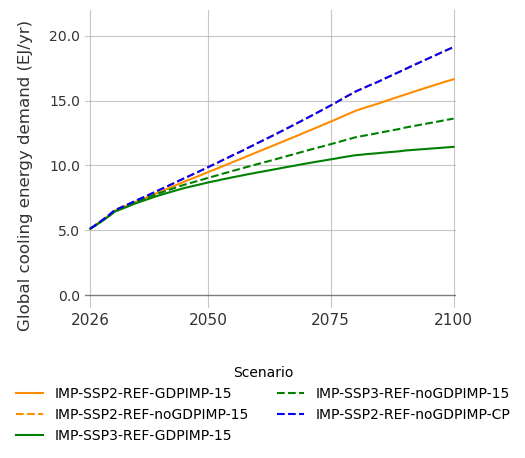

In [288]:
def plot_coolingdemand(variable_data, labels, colors, linestyles, title, y_label):

    fig, ax = plt.subplots(figsize=(5,4))  
    filtered_data = [data.where(data['year'] >= 2026, drop=True) for data in variable_data]
    filtered_data_ej = [data /1e9 for data in filtered_data]
    years = filtered_data[0]['year']    
    current_max = 0

    current_max = 0
    for data in filtered_data_ej:
        data_max = data.max().item() if hasattr(data.max(), 'item') else data.max()
        current_max = max(current_max, data_max)

    for j, data in enumerate(filtered_data_ej):
        plt.plot(years, data, color=colors[j], linestyle=linestyles[j], label=labels[j])

    ax.set_axisbelow(True)
    yticks = [0,5,10,15,20]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=10, color=GREY20)
    plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    xticks=[2026,2050,2075,2100]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, fontsize=11, color=GREY20)
    ax.grid(True, linestyle='-', axis='both', alpha=0.7)
    ax.set_ylim(-1, 1.15*current_max)
    ax.set_xlim(2025,2100.5)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.yaxis.set_tick_params(which="both", length=0)
    ax.xaxis.set_tick_params(which="both", length=0)
    ax.axhline(y=0, color=GREY20, linestyle='-', alpha=0.5, linewidth=1)
    
    fig.text(0.01, 0.5, y_label, va='center', rotation='vertical', fontsize=12, color=GREY20)
    legend = fig.legend(labels, loc='lower center', bbox_to_anchor=(0.5, -0.2),
               ncol=2, frameon=False, fontsize=10, title='Scenario', title_fontsize=10)
    plt.tight_layout(rect=[0.043, 0.08, 0.95, 0.95])
    plt.title('')
    # plt.savefig(FIG_DIR + f'{title}.pdf', bbox_inches='tight')
    plt.show()

scenarios = [
    'IMP-SSP2-REF-GDPIMP-15',
    'IMP-SSP2-REF-noGDPIMP-15',
    'IMP-SSP3-REF-GDPIMP-15',
    'IMP-SSP3-REF-noGDPIMP-15',
    'IMP-SSP2-REF-noGDPIMP-CP'
]

variable_data = [
    all_data[s]['energy_use'].sel(region=26, dim2=0, dim3=[0, 1, 2]).sum(dim='dim3')
    for s in scenarios
]

plot_coolingdemand(
    variable_data=variable_data,
    labels=scenarios,
    colors=['darkorange', 'darkorange', 'green', 'green', 'blue'],
    linestyles=['solid', 'dashed', 'solid', 'dashed', 'dashed'],
    title='cooling_demand_sparccle',
    y_label='Global cooling energy demand (EJ/yr)'
)

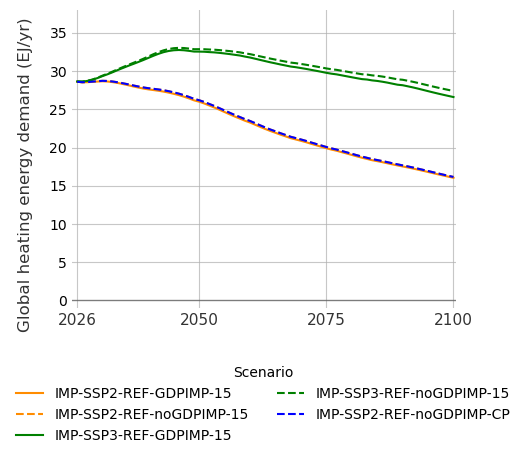

In [303]:
# heating demand (figure for Meike)
def plot_heatingdemand(variable_data, labels, colors, linestyles, title, y_label):

    fig, ax = plt.subplots(figsize=(5,4))  
    filtered_data = [data.where(data['year'] >= 2026, drop=True) for data in variable_data]
    filtered_data_ej = [data /1e3 for data in filtered_data]
    years = filtered_data[0]['year']    
    current_max = 0

    current_max = 0
    for data in filtered_data_ej:
        data_max = data.max().item() if hasattr(data.max(), 'item') else data.max()
        current_max = max(current_max, data_max)

    for j, data in enumerate(filtered_data_ej):
        plt.plot(years, data, color=colors[j], linestyle=linestyles[j], label=labels[j])

    ax.set_axisbelow(True)
    plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
    xticks=[2026,2050,2075,2100]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, fontsize=11, color=GREY20)
    ax.grid(True, linestyle='-', axis='both', alpha=0.7)
    ax.set_ylim(-1, 1.15*current_max)
    ax.set_xlim(2025,2100.5)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.yaxis.set_tick_params(which="both", length=0)
    ax.xaxis.set_tick_params(which="both", length=0)
    ax.axhline(y=0, color=GREY20, linestyle='-', alpha=0.5, linewidth=1)
    
    fig.text(0.01, 0.5, y_label, va='center', rotation='vertical', fontsize=12, color=GREY20)
    legend = fig.legend(labels, loc='lower center', bbox_to_anchor=(0.5, -0.2),
               ncol=2, frameon=False, fontsize=10, title='Scenario', title_fontsize=10)
    plt.tight_layout(rect=[0.043, 0.08, 0.95, 0.95])
    plt.title('')
    # plt.savefig(FIG_DIR + f'{title}.pdf', bbox_inches='tight')
    plt.show()

scenarios = [
    'IMP-SSP2-REF-GDPIMP-15',
    'IMP-SSP2-REF-noGDPIMP-15',
    'IMP-SSP3-REF-GDPIMP-15',
    'IMP-SSP3-REF-noGDPIMP-15',
    'IMP-SSP2-REF-noGDPIMP-CP'
]

variable_data = [
    all_data[s]['heating_2_energy_use'].sel(region=26, dim2=0)  #PJ/year, converted to EJ in function
    for s in scenarios
]

plot_heatingdemand(
    variable_data=variable_data,
    labels=scenarios,
    colors=['darkorange', 'darkorange', 'green', 'green', 'blue'],
    linestyles=['solid', 'dashed', 'solid', 'dashed', 'dashed'],
    title='heating_demand_sparccle',
    y_label='Global heating energy demand (EJ/yr)'
)

In [298]:
all_data['IMP-SSP2-REF-GDPIMP-15']['heating_2_energy_use'].sel(region=26, dim2=0)

<xarray.DataArray (year: 130)>
array([18396.85, 19217.09, 20013.27, 19926.99, 20245.88, 20953.15,
       21649.47, 21904.17, 22598.93, 22697.57, 23064.73, 23453.99,
       23962.1 , 25006.13, 25550.69, 25920.23, 26341.05, 26873.79,
       27089.68, 27661.71, 27342.71, 25868.31, 26091.86, 26201.03,
       26445.21, 27119.21, 27384.01, 27047.74, 27155.73, 27175.44,
       27485.17, 27299.74, 27398.85, 27129.04, 26911.33, 26598.66,
       26837.6 , 27182.36, 27215.08, 27478.32, 27862.78, 28223.36,
       28619.84, 29091.58, 29531.55, 29767.29, 29823.13, 29710.41,
       29808.5 , 31535.07, 30124.66, 29373.82, 29282.72, 29171.96,
       28678.19, 28605.05, 28534.76, 28548.89, 28588.87, 28632.61,
       28668.4 , 28630.63, 28552.49, 28442.06, 28304.56, 28156.68,
       27996.48, 27851.71, 27716.11, 27606.78, 27518.67, 27425.69,
       27314.61, 27180.94, 27026.2 , 26855.97, 26652.33, 26423.05,
       26168.91, 25991.3 , 25761.63, 25495.44, 25225.64, 24936.45,
       24639.27, 24343.25, 24052.48, 23784.21, 23504.16, 23266.46,
       22983.51, 22699.18, 22421.65, 22162.1 , 21927.49, 21680.96,
       21456.38, 21224.57, 21054.03, 20881.12, 20698.53, 20492.74,
       20299.13, 20105.36, 19912.  , 19730.21, 19584.96, 19396.65,
       19219.12, 19031.75, 18845.36, 18668.65, 18508.29, 18341.18,
       18219.23, 18086.83, 17943.46, 17799.9 , 17659.87, 17526.67,
       17397.05, 17256.79, 17108.72, 16957.95, 16804.24, 16646.98,
       16489.95, 16338.47, 16188.78, 16041.73])
Coordinates:
  * year     (year) int32 1971 1972 1973 1974 1975 ... 2096 2097 2098 2099 2100
    region   int32 26
    dim2     int32 0

**DATA ANALYSIS**    

In [198]:
def get_regional_cooling_gap(scenario, year):
    regional_gap = []
    for region in range(0,26):
        cooling_gap = all_data[scenario]['cooling_gap_pop'].sel(
            year=year,
            region=region,
            dim2=0
            )
        print(f"region {region+1} in {year} ({scenario}): {cooling_gap.values:.3e}")
        regional_gap.append(cooling_gap)
    return regional_gap

def get_global_cooling_gap(scenario, year):
    cooling_gap = all_data[scenario]['cooling_gap_pop'].sel(
        year=year,
        region=slice(0,25),
        dim2=0
    ).sum('region')
    print(f"cooling gap in {year} ({scenario}): {cooling_gap.values:.3e}")
    return cooling_gap

def get_regional_cooling_gap_share(scenario, year):
    regional_gap = []
    for region in range(0,26):
        cooling_gap = all_data[scenario]['cooling_gap_pop_share'].sel(
            year=year,
            region=region,
            dim2=0
            )
        print(f"region {region+1} in {year} ({scenario}): {cooling_gap.values:.3e}")
        regional_gap.append(cooling_gap)
    return regional_gap

In [195]:
scens = ['SSP2', 'SSP2_20D']
years = [2026, 2050, 2100]
         
cooling_gaps = {scen: {year: get_global_cooling_gap(scen, year) for year in years} for scen in scens}

for year in [2050, 2100]:
    absolute_diff = cooling_gaps['SSP2'][year] - cooling_gaps['SSP2_20D'][year]
    percent_diff = (cooling_gaps['SSP2_20D'][year] * 100 / cooling_gaps['SSP2'][year]) - 100
    print(f'\nAbsolute change SSP2 vs SSP2_20D in {year}: {absolute_diff.values:.3e}')
    print(f'% change SSP2 vs SSP2_20D in {year}: {percent_diff.values:.2f}%')

# Absolute change between 2026-2050
scen = 'SSP2'
abs_change_baseline = cooling_gaps[scen][2050] - cooling_gaps[scen][2026]
print(f'\nAbsolute change under {scen}, 2026 to 2050: {abs_change_baseline.values:.3e}')

cooling gap in 2026 (SSP2): 3.561e+09
cooling gap in 2050 (SSP2): 4.125e+09
cooling gap in 2100 (SSP2): 3.440e+09
cooling gap in 2026 (SSP2_20D): 3.561e+09
cooling gap in 2050 (SSP2_20D): 4.072e+09
cooling gap in 2100 (SSP2_20D): 3.220e+09

Absolute change SSP2 vs SSP2_20D in 2050: 5.279e+07
% change SSP2 vs SSP2_20D in 2050: -1.28%

Absolute change SSP2 vs SSP2_20D in 2100: 2.200e+08
% change SSP2 vs SSP2_20D in 2100: -6.39%

Absolute change under SSP2, 2026 to 2050: 5.636e+08


In [196]:
# comparing SSPs
ssps = ['SSP1', 'SSP3', 'SSP5']
years = [2050, 2100]

cooling_gaps_ssps = {ssp: {year: get_global_cooling_gap(ssp, year) for year in years} for ssp in ssps}
print()

# heat exposure
ssps = ['SSP1', 'SSP2', 'SSP3', 'SSP5']
year = 2050
for ssp in ssps:
    value = all_data[ssp]['heat_exposed_pop'].sel(year=year, region=26, dim2=0)
    print(f"pop exposed to heat in {ssp} in {year}: {value.values:.2e}")

cooling gap in 2050 (SSP1): 3.653e+09
cooling gap in 2100 (SSP1): 1.950e+09
cooling gap in 2050 (SSP3): 4.626e+09
cooling gap in 2100 (SSP3): 6.829e+09
cooling gap in 2050 (SSP5): 3.589e+09
cooling gap in 2100 (SSP5): 1.317e+09

pop exposed to heat in SSP1 in 2050: 7.00e+09
pop exposed to heat in SSP2 in 2050: 7.39e+09
pop exposed to heat in SSP3 in 2050: 7.81e+09
pop exposed to heat in SSP5 in 2050: 7.05e+09


In [199]:
ssp = ['SSP2_20D']
print(f"Population in the cooling gap per region:\n")
regional_cooling_gaps = {region: get_regional_cooling_gap(scenario=ssp[0], year=2050) for region in range(0,26)}

Population in the cooling gap per region:

region 1 in 2050 (SSP2_20D): 0.000e+00
region 2 in 2050 (SSP2_20D): 1.793e+03
region 3 in 2050 (SSP2_20D): 5.446e+07
region 4 in 2050 (SSP2_20D): 7.636e+07
region 5 in 2050 (SSP2_20D): 1.240e+08
region 6 in 2050 (SSP2_20D): 9.139e+07
region 7 in 2050 (SSP2_20D): 3.864e+07
region 8 in 2050 (SSP2_20D): 9.935e+08
region 9 in 2050 (SSP2_20D): 2.304e+08
region 10 in 2050 (SSP2_20D): 1.532e+07
region 11 in 2050 (SSP2_20D): 1.406e+02
region 12 in 2050 (SSP2_20D): 4.215e+06
region 13 in 2050 (SSP2_20D): 2.541e+07
region 14 in 2050 (SSP2_20D): 3.174e+06
region 15 in 2050 (SSP2_20D): 4.677e+07
region 16 in 2050 (SSP2_20D): 1.400e+07
region 17 in 2050 (SSP2_20D): 7.812e+06
region 18 in 2050 (SSP2_20D): 8.265e+08
region 19 in 2050 (SSP2_20D): 7.286e+06
region 20 in 2050 (SSP2_20D): 7.412e+06
region 21 in 2050 (SSP2_20D): 4.141e+08
region 22 in 2050 (SSP2_20D): 2.803e+08
region 23 in 2050 (SSP2_20D): 3.002e+02
region 24 in 2050 (SSP2_20D): 8.368e+04
region

In [200]:
# calculate global share of pop in cooling gap, weighted by regional population 
def calculate_pop_weighted_average(data_var, pop_data):
    weighted_data = data_var * pop_data
    weighted_average = weighted_data.sum(dim='region') / pop_data.sum(dim='region')
    return weighted_average

scens = ['SSP2', 'SSP2_20D']
years = [2026, 2050, 2100]

weighted_gaps = {
    scen: calculate_pop_weighted_average(
        all_data[scen]['cooling_gap_pop_share'].sel(dim2=0),
        all_data[scen]['pop'].sel(dim2=0)
    )
    for scen in scens
}
print('Share of global population in cooling gap (region-weighted average):\n')
for scen in scens:
    print(f'{scen}:')
    for year in years:
        value = weighted_gaps[scen].sel(year=year).values
        print(f"{year}: {value:.3e}")
    print()

Share of global population in cooling gap (region-weighted average):

SSP2:
2026: 4.312e-01
2050: 4.275e-01
2100: 3.455e-01

SSP2_20D:
2026: 4.312e-01
2050: 4.221e-01
2100: 3.234e-01



In [187]:
regions = {
    20: 'Southeast Asia',
    7: 'West Africa',
    9: 'South Africa'
}
scens = ['SSP2']
years = [2050, 2100]

print('Regional share of population in cooling gap:\n')
for scen in scens:
    print(f'{scen}:')
    for year in years:
        print(f'{year}:')
        for region, region_name in regions.items(): 
            value = all_data[scen]['cooling_gap_pop_share'].sel(year=year, region=region, dim2=0).values
            print(f'{region_name} (region {region+1}): {value:.3}')
        print()
    print()

Regional share of population in cooling gap:

SSP2:
2050:
Southeast Asia (region 21): 0.886
West Africa (region 8): 0.897
South Africa (region 10): 0.258

2100:
Southeast Asia (region 21): 0.831
West Africa (region 8): 0.713
South Africa (region 10): 0.345




In [215]:
def get_quintile_cooling_gap(scenario, regions, quintiles, year):
    # quintile_gap = []
    # for region in regions: 
    #     for quintile in quintiles:
    #         cooling_gap = all_data[scenario]['cooling_gap_pop_share'].sel(
    #             year=year,
    #             region=region,
    #             dim2=quintile
    #             )
    #         quintile_gap.append(cooling_gap)
    # return quintile_gap
    return [
        all_data[scenario]['cooling_gap_pop_share'].sel(year=year, region=region, dim2=q)
        for q in quintiles
    ]

regions ={
    'India': 17,
    'China': 19,
    'South Africa': 9,
    'EU': 10,
    'Russia': 15
}
quintiles = {
    'poorest': [3,8],
    'richest': [7,12]
}
scens = ['SSP2', 'SSP2_20D']
years=[2026,2050,2100]

print('Regional share of quintile population in cooling gap:\n')
for region_name, region_idx in regions.items():
    print(f'{region_name}:')
    for scen in scens:
        print(f' {scen}:')
        for q_name, q_indices in quintiles.items():
            print(f'  {q_name} quintile:')
            gap = get_quintile_cooling_gap(scen, region_idx, q_indices, years)
            for year in years:
                urban = gap[0].sel(year=year).values
                rural = gap[1].sel(year=year).values
                print(f'    {year}      urban: {urban:.3e}      rural: {rural:.3e}\n')

Regional share of quintile population in cooling gap:

India:
 SSP2:
  poorest quintile:
    2026      urban: 1.918e-01      rural: 1.950e-01

    2050      urban: 3.096e-01      rural: 3.241e-01

    2100      urban: 5.516e-01      rural: 5.870e-01

  richest quintile:
    2026      urban: 1.322e-01      rural: 1.800e-01

    2050      urban: 6.800e-02      rural: 1.521e-01

    2100      urban: 1.672e-04      rural: 1.494e-04

 SSP2_20D:
  poorest quintile:
    2026      urban: 1.918e-01      rural: 1.950e-01

    2050      urban: 2.674e-01      rural: 2.799e-01

    2100      urban: 2.729e-01      rural: 2.904e-01

  richest quintile:
    2026      urban: 1.322e-01      rural: 1.800e-01

    2050      urban: 5.872e-02      rural: 1.313e-01

    2100      urban: 8.273e-05      rural: 7.393e-05

China:
 SSP2:
  poorest quintile:
    2026      urban: 1.918e-01      rural: 1.950e-01

    2050      urban: 3.096e-01      rural: 3.241e-01

    2100      urban: 5.516e-01      rural: 5.870e-

ENERGY DEMAND

In [110]:
SSP = "SSP5"
YEARS = [2026, 2050, 2100]

SCEN_DICT = {
    "base": "",
    "adaptation": "_NO_GAP_ELEC",
    # "2dC": "_20D",
    # "adaptation_2dC": "_NO_GAP_ELEC_20D",
    # "adaptation_2dC_integ": "_NO_GAP_ELEC_SUST_20D",
}

SCENARIOS = {key: f"{SSP}{suffix}" for key, suffix in SCEN_DICT.items()}

def get_energy_demand(scenario, year):
    energy = all_data[scenario]["energy_use"].sel(
        year=year, region=26, dim2=0, dim3=slice(1, 2)
    ).sum("dim3")
    print(f"  energy demand {year} ({scenario}): {energy.values:e}")
    return energy


def percentage_change(new, ref):
    return (100 * new / ref - 100).values

# load data
print("Energy demand")
print(SSP)
energy = {}
for year in YEARS:
    print(f"\n[{year}]")
    for key, scen in SCENARIOS.items():
        if year == 2026 and key != "base":
            continue 
        energy[(key, year)] = get_energy_demand(scen, year)

print(f"\nAbsolute energy gap (adaptation vs base):")
for year in [2050, 2100]:
    gap = (energy[("adaptation", year)] - energy[("base", year)]).values
    print(f"  {year}: {gap:+e}")

# % changes
ref = energy[("base", 2026)]

comparisons = [
    # Growth from reference year
    ("base 2026 - 2050", energy[("base", 2050)], energy[("base", 2026)]),
    ("base 2026 - 2100", energy[("base", 2100)], energy[("base", 2026)]),
    # ("2dC 2026 - 2100", energy[("2dC", 2100)], energy[("base", 2026)]),
    ("adaptation 2026 - 2100", energy[("adaptation", 2100)], energy[("base", 2026)]),

    # Cross-scenario at same year
    ("adaptation vs base @ 2100", energy[("adaptation", 2100)], energy[("base", 2100)]),
    ("adaptation vs base @ 2050", energy[("adaptation", 2050)], energy[("base", 2050)]),
    # ("adaptation_2dC vs adaptation @ 2050", energy[("adaptation_2dC", 2050)], energy[("adaptation", 2050)]),
    # ("adaptation_2dC vs adaptation @ 2100", energy[("adaptation_2dC", 2100)], energy[("adaptation", 2100)]),
    # ("adaptation_2dC vs base @ 2050", energy[("adaptation_2dC", 2050)], energy[("base", 2050)]),
    # ("adaptation_2dC vs base @ 2100", energy[("adaptation_2dC", 2100)], energy[("base", 2100)]),
    # ("2dC vs base @ 2100", energy[("2dC", 2100)], energy[("base", 2100)]),
    # ("adaptation_2dC_integ vs base @ 2100", energy[("adaptation_2dC_integ", 2100)], energy[("base", 2100)]),
    # ("adaptation_2dC_integ vs adaptation_2dC @ 2050", energy[("adaptation_2dC_integ", 2050)], energy[("adaptation_2dC", 2050)]),
    # ("adaptation_2dC_integ vs adaptation_2dC @ 2100", energy[("adaptation_2dC_integ", 2100)], energy[("adaptation_2dC", 2100)]),
    # ("adaptation_2dC_integ vs base @ 2100", energy[("adaptation_2dC_integ", 2100)], energy[("base", 2100)]),
    # ("adaptation_2dC_integ vs adaptation @ 2100", energy[("adaptation_2dC_integ", 2100)], energy[("adaptation", 2100)]),
]

print("\n% changes:")
for label, num, denom in comparisons:
    print(f" {label}: {percentage_change(num, denom):+.2f} %")


Energy demand
SSP5

[2026]
  energy demand 2026 (SSP5): 3.619843e+09

[2050]
  energy demand 2050 (SSP5): 8.116835e+09
  energy demand 2050 (SSP5_NO_GAP_ELEC): 1.863765e+10

[2100]
  energy demand 2100 (SSP5): 2.030906e+10
  energy demand 2100 (SSP5_NO_GAP_ELEC): 2.501480e+10

Absolute energy gap (adaptation vs base):
  2050: +1.052081e+10
  2100: +4.705740e+09

% changes:
 base 2026 - 2050: +124.23 %
 base 2026 - 2100: +461.05 %
 adaptation 2026 - 2100: +591.05 %
 adaptation vs base @ 2100: +23.17 %
 adaptation vs base @ 2050: +129.62 %


In [265]:
def get_regional_energy_demand(scenario, year, regions):
    return {
        region: all_data[scenario]['energy_use'].sel(
            year=year,
            region=region,
            dim2=0,
            dim3=slice(1, 2)
        ).sum('dim3')
        for region in regions
    }

regions = {
    'West Africa': 7,
    'South Africa': 9,
    'East Africa': 10
}
scens = ['SSP2', 'SSP2_NO_GAP_ELEC', 'SSP2_NO_GAP_ELEC_20D']
years = [2100]

print('Regional energy demand (EJ):')
energy = {}
for scen in scens:
    energy[scen] = {}
    for year in years:
        energy[scen][year] = get_regional_energy_demand(scen, year, regions.values())
        print(f"\n{scen} in {year}:")
        for region_name, region_idx in regions.items():
            value = energy[scen][year][region_idx].values
            print(f"  {region_name} (region {region_idx+1}): {value:.3e}")

# % reduction from Adaptation to Adaptation-Mitigation
year = 2100
scen_ref = 'SSP2_NO_GAP_ELEC'
scen_new = 'SSP2_NO_GAP_ELEC_20D'
print(f'\n% reduction between {scen_ref} and {scen_new} in {year}:')
for region_name, region_id in regions.items():
    ref = energy[scen_ref][year][region_id]
    new = energy[scen_new][year][region_id]
    pct = 100 - (new * 100 / ref).values
    print(f'  {region_name}: {pct:.2f}%')

Regional energy demand (EJ):

SSP2 in 2100:
  West Africa (region 8): 2.046e+09
  South Africa (region 10): 1.993e+07
  East Africa (region 11): 9.084e+07

SSP2_NO_GAP_ELEC in 2100:
  West Africa (region 8): 6.343e+09
  South Africa (region 10): 4.744e+07
  East Africa (region 11): 9.166e+07

SSP2_NO_GAP_ELEC_20D in 2100:
  West Africa (region 8): 2.587e+09
  South Africa (region 10): 1.990e+07
  East Africa (region 11): 4.957e+07

% reduction between SSP2_NO_GAP_ELEC and SSP2_NO_GAP_ELEC_20D in 2100:
  West Africa: 59.22%
  South Africa: 58.05%
  East Africa: 45.92%


In [30]:
# compare heating use changes to cooling changes (to assess trade-offs)
heating_mitig_2100 = all_data['SSP2_20D']['heating_energy_use'].sel(year=2100, dim2=0).sum(dim='region').values
heating_adapt_2100 = all_data['SSP2_NO_GAP_ELEC']['heating_energy_use'].sel(year=2100, dim2=0).sum(dim='region').values
print(heating_mitig_2100)

print('Heating energy use difference between mitigation and adaptation in 2100 (in EJ):')
print(f'{heating_mitig_2100-heating_adapt_2100:.2e}')

14343088649.336
Heating energy use difference between mitigation and adaptation in 2100 (in EJ):
4.66e+08


In [255]:
# emissions results

scens = [
    "SSP2",
    "SSP2_20D",
    "SSP2_NO_GAP_ELEC",
    "SSP2_NO_GAP_ELEC_20D",
    "SSP2_NO_GAP_ELEC_SUST_20D"
    ]
region_dict = {
    "Brazil":  4,
    "W Africa": 7,
    "S Africa": 9,
    "Russia":  15,
    "India":   17,
    "China":   19,
}
global_region = 27

emis = {
    scen: all_data[scen]["emis"]
               .sel(dim2=20, dim3=6)
               .sel(year=slice(2025, 2050))
    for scen in scens
}

def relative_gap(da_new, da_ref, region=None):
    gap = (da_new - da_ref) / da_ref * 100
    return gap.sel(region=region) if region is not None else gap


def print_max_gap(gap):
    max_year = gap["year"].values[gap.argmax().item()]
    print(f"  Year of greatest gap : {max_year}")
    print(f"  Greatest relative gap: +{gap.sel(year=max_year).values:.4f} %")


###
print("\nGlobal emissions:\n")
global_gap_pairs = [
    ("SSP2_NO_GAP_ELEC", "SSP2"),
    ("SSP2_NO_GAP_ELEC_20D", "SSP2_20D"),
    ("SSP2_NO_GAP_ELEC_SUST_20D", "SSP2_20D"),
]
regional_gap_pair = ("SSP2_NO_GAP_ELEC_SUST_20D", "SSP2_20D")
use_relative_gap = True
###

print(
    f"Global emissions in SSP2 in 2048\n(2048 is the year with the greatest emissions gap between SSP2_NO_GAP_ELEC_SUST_20D & SSP2_20D): "
    f"{emis['SSP2'].sel(year=2048, region=global_region).values:.3f} Gt CO2/yr"
)

for scen_new, scen_ref in global_gap_pairs:
    gap = relative_gap(emis[scen_new], emis[scen_ref], region=global_region)
    print(f"\n{scen_new} vs {scen_ref}:")
    print_max_gap(gap)

scen_new, scen_ref = regional_gap_pair
if use_relative_gap:
    emis_gap_regional = relative_gap(emis[scen_new], emis[scen_ref])
    unit = "%"
else:
    emis_gap_regional = emis[scen_new] - emis[scen_ref]
    unit = "Gt CO2/yr"

print(f"\nRegional emissions gap ({scen_new} vs {scen_ref}) [{unit}]:")
for region_name, region_id in region_dict.items():
    gap = emis_gap_regional.sel(region=region_id)
    max_year = gap["year"].values[gap.argmax().item()]
    print(f"\n  {region_name}: {gap.max().values:.3f} {unit} in {max_year}")
    print(emis[scen_ref].sel(year=max_year, region=region_id).values)


Global emissions:

Global emissions in SSP2 in 2048
(2048 is the year with the greatest emissions gap between SSP2_NO_GAP_ELEC_SUST_20D & SSP2_20D): 10.327 Gt CO2/yr

SSP2_NO_GAP_ELEC vs SSP2:
  Year of greatest gap : 2050
  Greatest relative gap: +4.2803 %

SSP2_NO_GAP_ELEC_20D vs SSP2_20D:
  Year of greatest gap : 2048
  Greatest relative gap: +2.5673 %

SSP2_NO_GAP_ELEC_SUST_20D vs SSP2_20D:
  Year of greatest gap : 2047
  Greatest relative gap: +2.5975 %

Regional emissions gap (SSP2_NO_GAP_ELEC_SUST_20D vs SSP2_20D) [%]:

  Brazil: 0.401 % in 2046
0.09309672

  W Africa: 262.319 % in 2048
0.02022321

  S Africa: 1.104 % in 2037
0.08293944

  Russia: 0.396 % in 2045
0.352475

  India: 7.380 % in 2050
0.3374981

  China: 2.933 % in 2044
0.9156929


In [257]:
# temperature change

def get_gmt(scen, year):
    return all_data[scen]["gmt"].sel(year=year).item()

year = 2026
print(f"GMT in {year}: {get_gmt('SSP2', year):.4f} °C\n")

year = 2050
for scen, label in scen_dict.items():
    print(f"GMT in {year} — {label:<26}: {get_gmt(scen, year):.3f} °C")

GMT in 2026: 1.2145 °C

GMT in 2050 — base                      : 1.781 °C
GMT in 2050 — 2dC                       : 1.599 °C
GMT in 2050 — adaptation                : 1.790 °C
GMT in 2050 — adaptation_2dC            : 1.603 °C
GMT in 2050 — integ_adaptation_2dC      : 1.601 °C
